## metabolite trajectories

In [1]:
from mcschematic_plus import MCSchematicPlus
import numpy as np
from pathlib import Path
path_cell = Path("martini3.npy")

In [2]:
cell = np.load(path_cell)[0]

In [3]:
# create static structures for each component
# ordering is determines which component gets priority if overlap. earlier has higher priority.
components = {
    "membrane": "minecraft:lime_stained_glass",
    "membrane_proteins": "minecraft:blue_concrete",
    "cytosolic_proteins": "minecraft:red_concrete",
    "dna": "minecraft:yellow_concrete",
    "rna": "minecraft:cyan_concrete",
    "metabolites": "minecraft:purple_concrete"
}

In [4]:
# create a schematic for each component separately.
for i, component in enumerate(components.keys()):
    component_schem = MCSchematicPlus()
    vol = cell[..., i] # already bool
    # mask any previously placed components to avoid overlap
    for j in range(i):
        vol = vol & ~cell[..., j]
    component_schem.placeVolume(vol, components[component])
    component_schem.save(f"schematics/martini3_{component}.schem")

In [5]:
# create one single schematic containing all components
schem = MCSchematicPlus()
for i, component in enumerate(components.keys()):
    vol = cell[..., i] # already bool
    # mask any previously placed components to avoid overlap
    for j in range(i):
        vol = vol & ~cell[..., j]
    schem.placeVolume(vol, components[component])

schem.save("schematics/martini3.schem")

C:\Users\public.QCB-MC-VR\Documents\GitHub\Kevin File converter\mcschematic-plus\src\mcschematic_plus\mcschematic_plus.py:392: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  p.show(**kwargs)


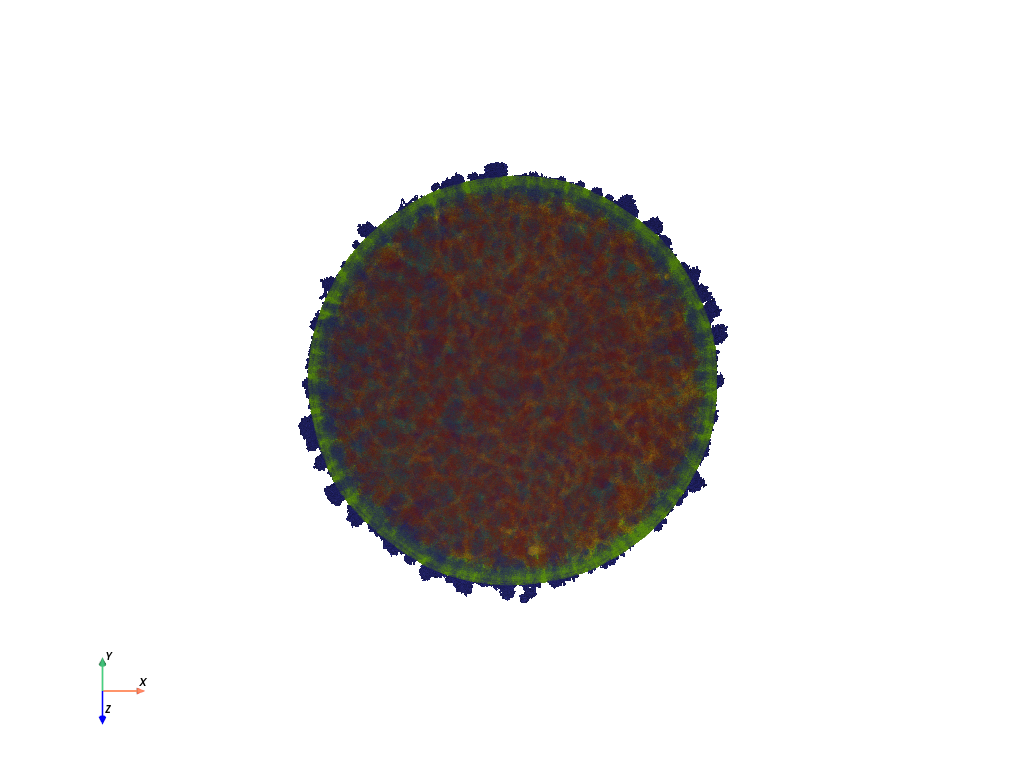

In [6]:
plotter = schem.show()

In [ ]:
# # save metabolite trajectories
# for i in range(0, 1121):
#     metabolite_schem = MCSchematicPlus()
#     metabolite_schem.setBlocks(metabolite[i]/10, "minecraft:purple_concrete") # angstrom to nm
#     metabolite_schem.save(f"metabolite_schematics/martini2_metabolites_{i:04d}.schem")

## Animate all membrane proteins (was too slow)

In [ ]:
# from mcschematic_plus import MCSchematicPlus
# import numpy as np
# from pathlib import Path

In [ ]:
# path = Path("martini3_syn3A_envelope_small.npy")
# martini_timelapse = np.load(path)

In [ ]:
# for i in range(10):
#     schem = MCSchematicPlus()
#     schem.placeVolume(martini_timelapse[i] == 1, "minecraft:lime_stained_glass")
#     schem.placeVolume(martini_timelapse[i] == 2, "minecraft:red_concrete")
#     schem.save(f"schematics/{path.stem}_{i:03d}.schem")

In [ ]:
# (martini_timelapse[0]!=0).sum()

751190